In [12]:
pip install ucimlrepo


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\aisha\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [13]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
bank_marketing = fetch_ucirepo(id=222) 
  
# data (as pandas dataframes) 
X = bank_marketing.data.features 
y = bank_marketing.data.targets 
  
# metadata 
print(bank_marketing.metadata) 
  
# variable information 
print(bank_marketing.variables) 


{'uci_id': 222, 'name': 'Bank Marketing', 'repository_url': 'https://archive.ics.uci.edu/dataset/222/bank+marketing', 'data_url': 'https://archive.ics.uci.edu/static/public/222/data.csv', 'abstract': 'The data is related with direct marketing campaigns (phone calls) of a Portuguese banking institution. The classification goal is to predict if the client will subscribe a term deposit (variable y).', 'area': 'Business', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 45211, 'num_features': 16, 'feature_types': ['Categorical', 'Integer'], 'demographics': ['Age', 'Occupation', 'Marital Status', 'Education Level'], 'target_col': ['y'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 2014, 'last_updated': 'Fri Aug 18 2023', 'dataset_doi': '10.24432/C5K306', 'creators': ['S. Moro', 'P. Rita', 'P. Cortez'], 'intro_paper': {'ID': 277, 'type': 'NATIVE', 'title': 'A data-driven approach to predict the s

In [14]:
from ucimlrepo import fetch_ucirepo
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

bank_marketing = fetch_ucirepo(id=222)

# X only (features only)
X = bank_marketing.data.features.copy()

X.head()

,age,job,marital,education,default,balance,housing,loan,contact,day_of_week,month,duration,campaign,pdays,previous,poutcome
0,58,management,married,tertiary,no,2143,yes,no,NaN,5,may,261,1,-1,0,NaN
1,44,technician,single,secondary,no,29,yes,no,NaN,5,may,151,1,-1,0,NaN
2,33,entrepreneur,married,secondary,no,2,yes,yes,NaN,5,may,76,1,-1,0,NaN
3,47,blue-collar,married,NaN,no,1506,yes,no,NaN,5,may,92,1,-1,0,NaN
4,33,NaN,single,NaN,no,1,no,no,NaN,5,may,198,1,-1,0,NaN


In [15]:
num_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = X.select_dtypes(exclude=["int64", "float64"]).columns.tolist()

print("Numeric columns:", num_cols)
print("Categorical columns:", cat_cols)

Numeric columns: ['age', 'balance', 'day_of_week', 'duration', 'campaign', 'pdays', 'previous']
Categorical columns: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']


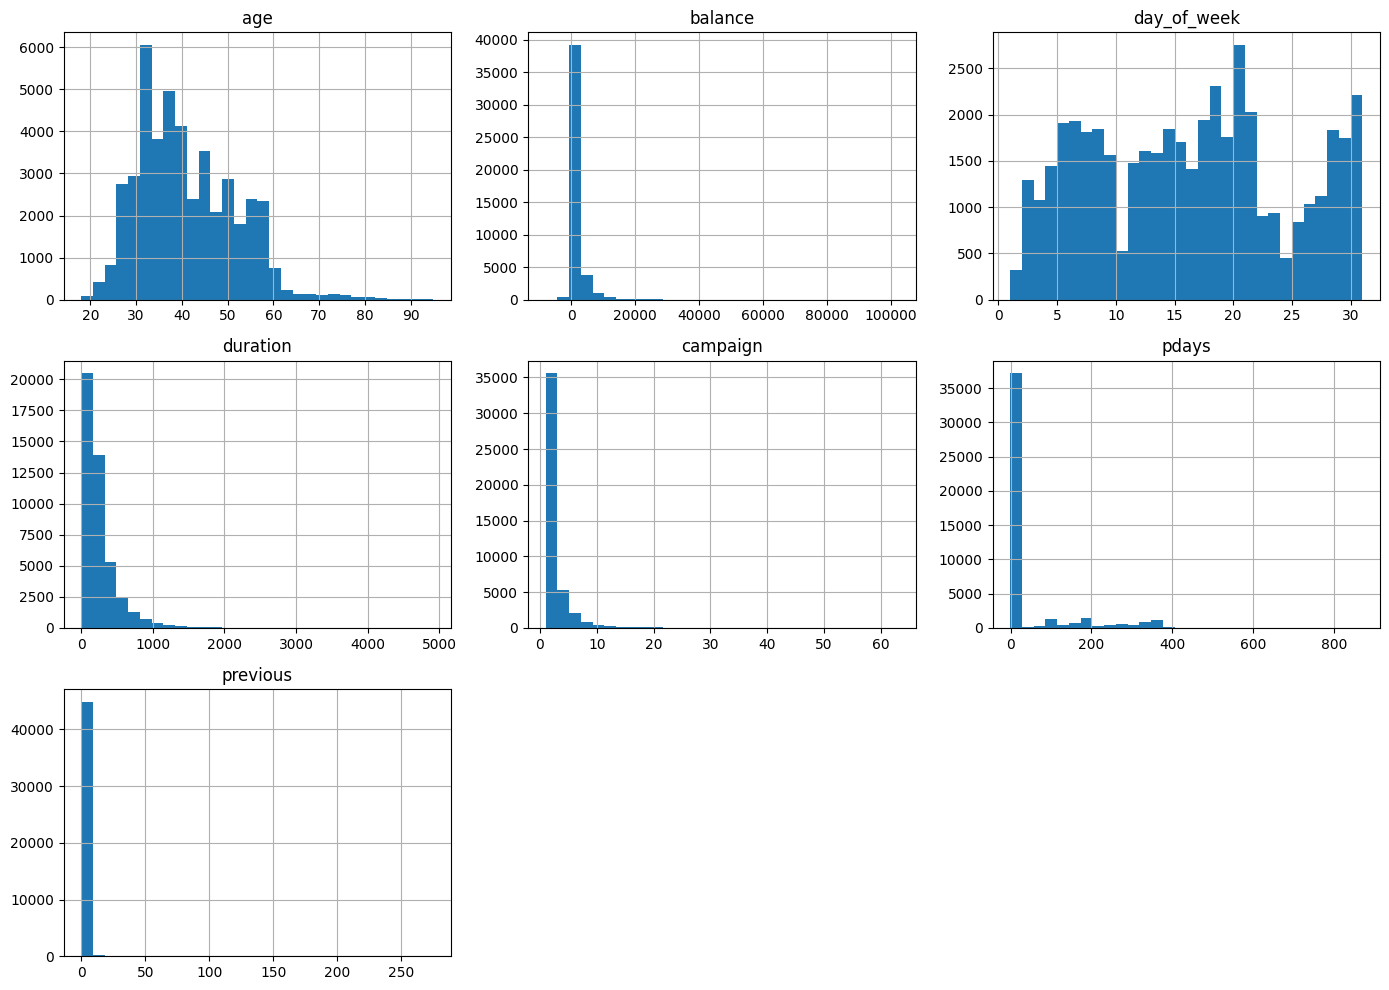

In [16]:
numeric_stats = X[num_cols].describe().T
numeric_stats["skewness"] = X[num_cols].skew()

numeric_stats

X[num_cols].hist(figsize=(14,10), bins=30)
plt.tight_layout()
plt.show()

In [17]:
for col in cat_cols:
    print(f"\n==== {col} ====")
    print(X[col].value_counts(dropna=False))


==== job ====
job
blue-collar      9732
management       9458
technician       7597
admin.           5171
services         4154
retired          2264
self-employed    1579
entrepreneur     1487
unemployed       1303
housemaid        1240
student           938
NaN               288
Name: count, dtype: int64

==== marital ====
marital
married     27214
single      12790
divorced     5207
Name: count, dtype: int64

==== education ====
education
secondary    23202
tertiary     13301
primary       6851
NaN           1857
Name: count, dtype: int64

==== default ====
default
no     44396
yes      815
Name: count, dtype: int64

==== housing ====
housing
yes    25130
no     20081
Name: count, dtype: int64

==== loan ====
loan
no     37967
yes     7244
Name: count, dtype: int64

==== contact ====
contact
cellular     29285
NaN          13020
telephone     2906
Name: count, dtype: int64

==== month ====
month
may    13766
jul     6895
aug     6247
jun     5341
nov     3970
apr     2932
feb     2

In [18]:
import numpy as np

X = X.replace("unknown", np.nan)

print(X.isna().sum())

num_cols = X.select_dtypes(include=["int64", "float64"]).columns
X[num_cols] = X[num_cols].apply(lambda col: col.fillna(col.median()))

cat_cols = X.select_dtypes(exclude=["int64", "float64"]).columns
X[cat_cols] = X[cat_cols].apply(lambda col: col.fillna(col.mode()[0]))

print("Remaining missing values:\n", X.isna().sum().sum())

age                0
job              288
marital            0
education       1857
default            0
balance            0
housing            0
loan               0
contact        13020
day_of_week        0
month              0
duration           0
campaign           0
pdays              0
previous           0
poutcome       36959
dtype: int64
Remaining missing values:
 0


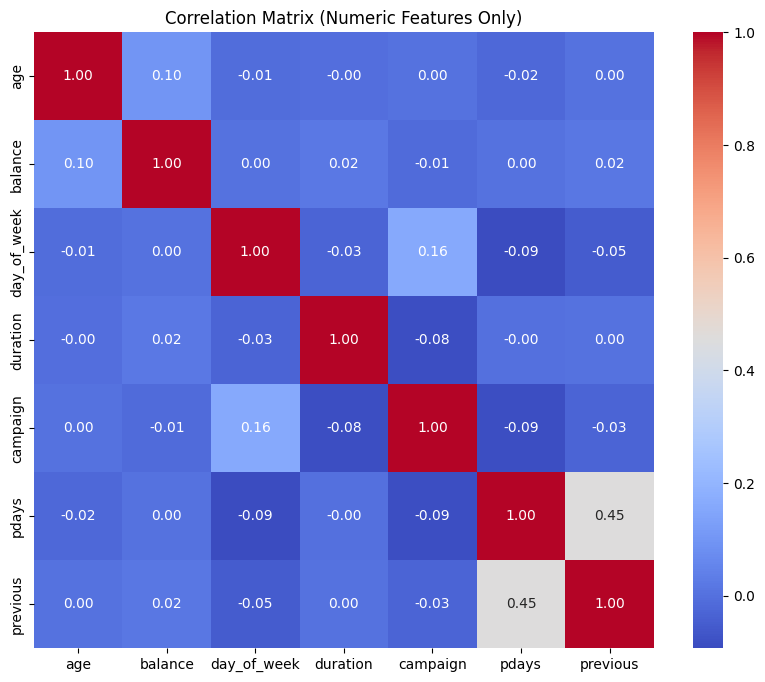

In [19]:
corr = X_clean[num_cols].corr(numeric_only=True)

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix (Numeric Features Only)")
plt.show()

In [20]:
outlier_report = {}

for col in num_cols:
    s = X_clean[col].dropna()
    Q1 = s.quantile(0.25)
    Q3 = s.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outlier_count = ((s < lower) | (s > upper)).sum()
    outlier_report[col] = outlier_count

pd.Series(outlier_report).sort_values(ascending=False)

previous       8257
pdays          8257
balance        4729
duration       3235
campaign       3064
age             487
day_of_week       0
dtype: int64

In [21]:
from sklearn.preprocessing import OneHotEncoder

# Separate numeric and categorical
num_cols = X.select_dtypes(include=["int64", "float64"]).columns
cat_cols = X.select_dtypes(exclude=["int64", "float64"]).columns

# One-hot encode categorical columns
X_encoded = pd.get_dummies(X, columns=cat_cols, drop_first=True)

X_encoded.head()

,age,balance,day_of_week,duration,campaign,pdays,previous,job_blue-collar,job_entrepreneur,job_housemaid,...,month_jan,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_other,poutcome_success
0,58,2143,5,261,1,-1,0,False,False,False,...,False,False,False,False,True,False,False,False,False,False
1,44,29,5,151,1,-1,0,False,False,False,...,False,False,False,False,True,False,False,False,False,False
2,33,2,5,76,1,-1,0,False,True,False,...,False,False,False,False,True,False,False,False,False,False
3,47,1506,5,92,1,-1,0,True,False,False,...,False,False,False,False,True,False,False,False,False,False
4,33,1,5,198,1,-1,0,True,False,False,...,False,False,False,False,True,False,False,False,False,False


In [22]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_encoded)

# Convert back to DataFrame (optional but cleaner)
X_scaled = pd.DataFrame(X_scaled, columns=X_encoded.columns)

X_scaled.head()

,age,balance,day_of_week,duration,campaign,pdays,previous,job_blue-collar,job_entrepreneur,job_housemaid,...,month_jan,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_other,poutcome_success
0,1.606965,0.256419,-1.298476,0.011016,-0.569351,-0.411453,-0.25194,-0.533603,-0.184415,-0.16793,...,-0.178958,-0.424206,-0.366006,-0.103262,1.511374,-0.310263,-0.128819,-0.113898,-0.205972,-0.185948
1,0.288529,-0.437895,-1.298476,-0.416127,-0.569351,-0.411453,-0.25194,-0.533603,-0.184415,-0.16793,...,-0.178958,-0.424206,-0.366006,-0.103262,1.511374,-0.310263,-0.128819,-0.113898,-0.205972,-0.185948
2,-0.747384,-0.446762,-1.298476,-0.707361,-0.569351,-0.411453,-0.25194,-0.533603,5.422561,-0.16793,...,-0.178958,-0.424206,-0.366006,-0.103262,1.511374,-0.310263,-0.128819,-0.113898,-0.205972,-0.185948
3,0.571051,0.047205,-1.298476,-0.645231,-0.569351,-0.411453,-0.25194,1.874053,-0.184415,-0.16793,...,-0.178958,-0.424206,-0.366006,-0.103262,1.511374,-0.310263,-0.128819,-0.113898,-0.205972,-0.185948
4,-0.747384,-0.447091,-1.298476,-0.233620,-0.569351,-0.411453,-0.25194,1.874053,-0.184415,-0.16793,...,-0.178958,-0.424206,-0.366006,-0.103262,1.511374,-0.310263,-0.128819,-0.113898,-0.205972,-0.185948


In [23]:
print("Missing values:", X_scaled.isna().sum().sum())
print("Data types:\n", X_scaled.dtypes.unique())

Missing values: 0
Data types:
 [dtype('float64')]


In [24]:
from sklearn.cluster import KMeans

k = 3
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
kmeans.fit(X_scaled)

,n_clusters,3
,init,'k-means++'
,n_init,10
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [25]:
labels = kmeans.labels_
labels[:10]   # show first 10 cluster assignments

array([1, 0, 0, 0, 0, 1, 1, 1, 2, 0], dtype=int32)

In [26]:
X_clustered = X_scaled.copy()
X_clustered["cluster"] = labels

X_clustered.head()

,age,balance,day_of_week,duration,campaign,pdays,previous,job_blue-collar,job_entrepreneur,job_housemaid,...,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_other,poutcome_success,cluster
0,1.606965,0.256419,-1.298476,0.011016,-0.569351,-0.411453,-0.25194,-0.533603,-0.184415,-0.16793,...,-0.424206,-0.366006,-0.103262,1.511374,-0.310263,-0.128819,-0.113898,-0.205972,-0.185948,1
1,0.288529,-0.437895,-1.298476,-0.416127,-0.569351,-0.411453,-0.25194,-0.533603,-0.184415,-0.16793,...,-0.424206,-0.366006,-0.103262,1.511374,-0.310263,-0.128819,-0.113898,-0.205972,-0.185948,0
2,-0.747384,-0.446762,-1.298476,-0.707361,-0.569351,-0.411453,-0.25194,-0.533603,5.422561,-0.16793,...,-0.424206,-0.366006,-0.103262,1.511374,-0.310263,-0.128819,-0.113898,-0.205972,-0.185948,0
3,0.571051,0.047205,-1.298476,-0.645231,-0.569351,-0.411453,-0.25194,1.874053,-0.184415,-0.16793,...,-0.424206,-0.366006,-0.103262,1.511374,-0.310263,-0.128819,-0.113898,-0.205972,-0.185948,0
4,-0.747384,-0.447091,-1.298476,-0.233620,-0.569351,-0.411453,-0.25194,1.874053,-0.184415,-0.16793,...,-0.424206,-0.366006,-0.103262,1.511374,-0.310263,-0.128819,-0.113898,-0.205972,-0.185948,0


In [27]:
X_clustered["cluster"].value_counts().sort_index()

cluster
0    29633
1    13311
2     2267
Name: count, dtype: int64

In [28]:
centers = pd.DataFrame(kmeans.cluster_centers_, columns=X_scaled.columns)
centers.head()

,age,balance,day_of_week,duration,campaign,pdays,previous,job_blue-collar,job_entrepreneur,job_housemaid,...,month_jan,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_other,poutcome_success
0,-0.073952,-0.076511,-0.012422,-0.004670,-0.000559,0.009099,-0.016635,0.266132,-0.034338,0.052166,...,-0.011366,0.016962,0.020393,-0.038182,0.104597,-0.034295,-0.041451,-0.038251,0.001066,-0.047919
1,-0.167568,0.135396,0.034945,-0.009052,0.024213,-0.015616,0.032660,-0.501240,0.107365,-0.087929,...,0.017211,-0.036331,-0.053557,0.054018,-0.177831,0.092765,0.033553,0.039038,0.001149,0.065148
2,1.950802,0.204550,-0.042940,0.114213,-0.134929,-0.027184,0.025548,-0.533603,-0.181941,-0.165229,...,0.047442,-0.008262,0.048090,0.181681,-0.322324,-0.096736,0.344610,0.270566,-0.020678,0.243547


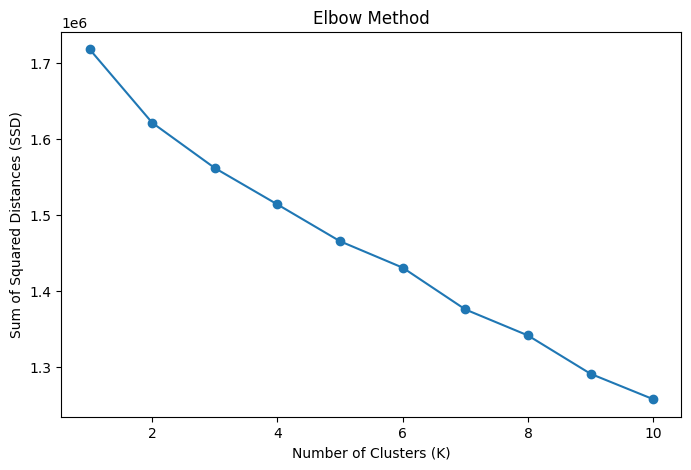

In [29]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

ssd = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    ssd.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K_range, ssd, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Sum of Squared Distances (SSD)")
plt.title("Elbow Method")
plt.show()

In [30]:
from sklearn.metrics import silhouette_score

sil_scores = []

for k in range(2, 11):  # silhouette needs at least 2 clusters
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    sil_scores.append(score)
    print(f"K = {k}, Silhouette Score = {score:.4f}")

K = 2, Silhouette Score = 0.0852
K = 3, Silhouette Score = 0.0961
K = 4, Silhouette Score = 0.0713
K = 5, Silhouette Score = 0.1023
K = 6, Silhouette Score = 0.0713
K = 7, Silhouette Score = 0.0801
K = 8, Silhouette Score = 0.0916
K = 9, Silhouette Score = 0.1087
K = 10, Silhouette Score = 0.1020


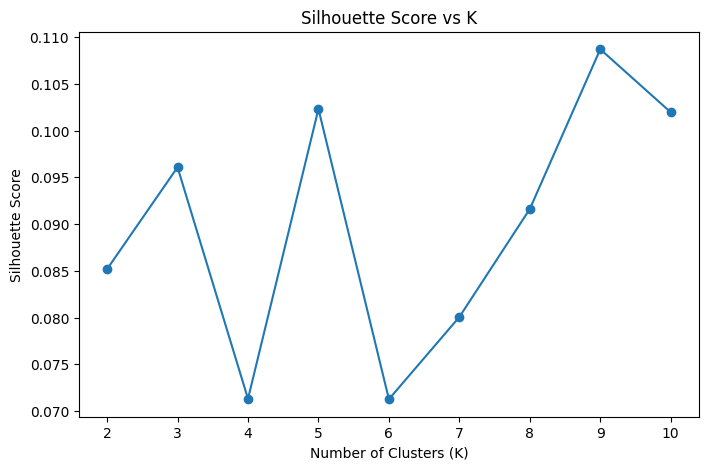

In [31]:
plt.figure(figsize=(8,5))
plt.plot(range(2,11), sil_scores, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs K")
plt.show()